In [6]:
import numpy as np
import pandas as pd
import time
import json
import matplotlib.pyplot as plt

plt.rcParams.update({'figure.max_open_warning': 0})

def sequential_search_with_steps(arr, target):
    steps = 0
    for i, x in enumerate(arr):
        steps += 1
        if x == target:
            return i, steps, True
    return -1, steps, False

def binary_search_with_steps(arr, target):
    low, high = 0, len(arr) - 1
    steps = 0
    while low <= high:
        mid = (low + high) // 2
        steps += 1
        if arr[mid] == target:
            return mid, steps, True
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1, steps, False

def time_call(func, *args, **kwargs):
    start = time.perf_counter()
    res = func(*args, **kwargs)
    end = time.perf_counter()
    return end - start, res

# baseline data (used by several cells)
with open('gudang.json', encoding='utf-8') as f:
    gudang = json.load(f)
data = sorted(item['id'] for item in gudang)


### Bar Chart Waktu Eksekusi

Membandingkan rata‑rata waktu eksekusi Sequential vs Binary pada pencarian target yang ada, sehingga terlihat perbedaan kecepatan.

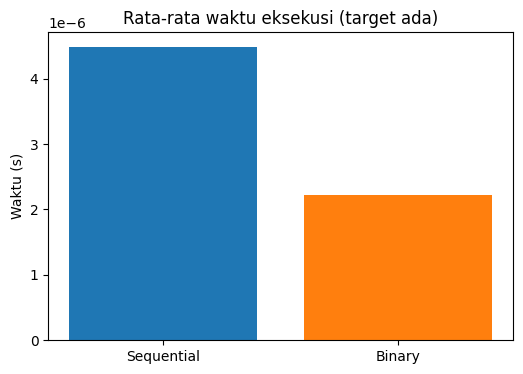

In [7]:
# Bar Chart – Waktu eksekusi rata-rata
num_searches = len(data)
times = {'Sequential': [], 'Binary': []}
for _ in range(num_searches):
    target = np.random.choice(data)
    t_seq, (_idx, _steps, _found) = time_call(lambda a,t: sequential_search_with_steps(a, t), data, target)
    t_bin, (_idx, _steps, _found) = time_call(lambda a,t: binary_search_with_steps(a, t), data, target)
    times['Sequential'].append(t_seq)
    times['Binary'].append(t_bin)

df_times = pd.DataFrame(times)
means = df_times.mean()
plt.figure(figsize=(6,4))
plt.bar(['Sequential','Binary'], means.values, color=['C0','C1'])
plt.ylabel('Waktu (s)')
plt.title('Rata-rata waktu eksekusi (target ada)')
plt.show()


### Bar Chart Jumlah Langkah

Menilai efisiensi algoritma berdasarkan jumlah perbandingan rata‑rata yang diperlukan untuk menemukan target.

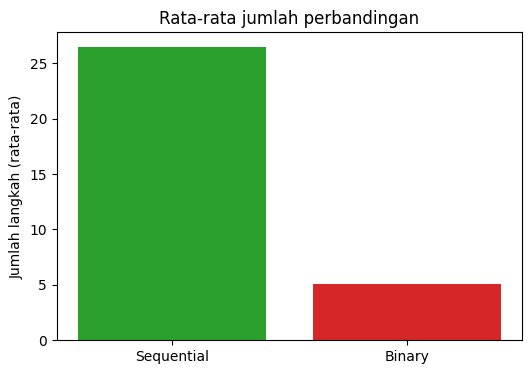

In [8]:
# Bar Chart – Jumlah perbandingan rata-rata
num_searches = len(data)
steps = {'Sequential': [], 'Binary': []}
for _ in range(num_searches):
    target = np.random.choice(data)
    (_idx, s_seq, _found) = sequential_search_with_steps(data, target)
    (_idx, s_bin, _found) = binary_search_with_steps(data, target)
    steps['Sequential'].append(s_seq)
    steps['Binary'].append(s_bin)

df_steps = pd.DataFrame(steps)
means_steps = df_steps.mean()
plt.figure(figsize=(6,4))
plt.bar(['Sequential','Binary'], means_steps.values, color=['C2','C3'])
plt.ylabel('Jumlah langkah (rata-rata)')
plt.title('Rata-rata jumlah perbandingan')
plt.show()


### Line Chart Waktu vs Ukuran Dataset

Menunjukkan bagaimana waktu eksekusi kedua algoritma bertumbuh seiring bertambahnya ukuran data (linear vs logaritmik).

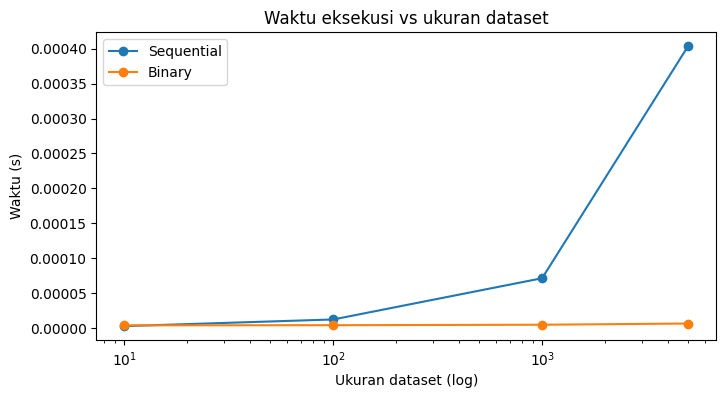

In [9]:
# Line Chart – Waktu vs ukuran dataset
sizes = [10, 100, 1000, 5000]
times_vs = {'Sequential': [], 'Binary': []}
repeats = 50
for size in sizes:
    arr = np.random.randint(0, 10000, size=size)
    arr.sort()
    t_seq_list = []
    t_bin_list = []
    for _ in range(repeats):
        target = np.random.choice(arr)
        t_seq, (_i,_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
        t_bin, (_i,_s,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
        t_seq_list.append(t_seq)
        t_bin_list.append(t_bin)
    times_vs['Sequential'].append(np.mean(t_seq_list))
    times_vs['Binary'].append(np.mean(t_bin_list))

plt.figure(figsize=(8,4))
plt.plot(sizes, times_vs['Sequential'], marker='o', label='Sequential')
plt.plot(sizes, times_vs['Binary'], marker='o', label='Binary')
plt.xscale('log')
plt.xlabel('Ukuran dataset (log)')
plt.ylabel('Waktu (s)')
plt.title('Waktu eksekusi vs ukuran dataset')
plt.legend()
plt.show()


### Line Chart Langkah vs Ukuran Dataset

Memvisualisasikan pertumbuhan jumlah langkah pencarian terhadap ukuran dataset, memperlihatkan pola O(n) vs O(log n).

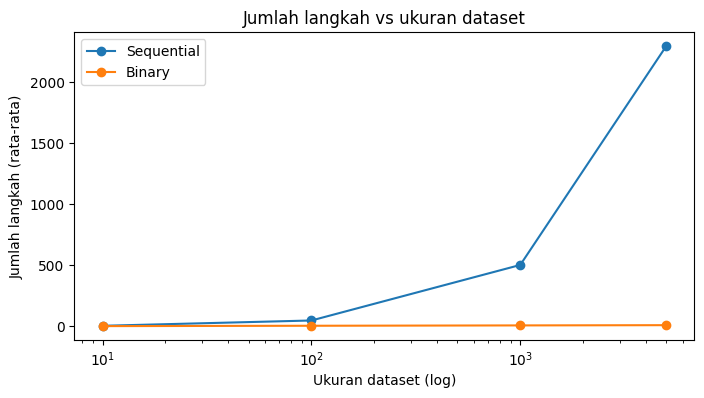

In [10]:
# 4) Line Chart – Jumlah langkah vs ukuran dataset
sizes = [10, 100, 1000, 5000]
steps_vs = {'Sequential': [], 'Binary': []}
repeats = 50
for size in sizes:
    arr = np.random.randint(0, 10000, size=size)
    arr.sort()
    s_seq_list = []
    s_bin_list = []
    for _ in range(repeats):
        target = np.random.choice(arr)
        (_i, s_seq, _f) = sequential_search_with_steps(arr, target)
        (_i, s_bin, _f) = binary_search_with_steps(arr, target)
        s_seq_list.append(s_seq)
        s_bin_list.append(s_bin)
    steps_vs['Sequential'].append(np.mean(s_seq_list))
    steps_vs['Binary'].append(np.mean(s_bin_list))

plt.figure(figsize=(8,4))
plt.plot(sizes, steps_vs['Sequential'], marker='o', label='Sequential')
plt.plot(sizes, steps_vs['Binary'], marker='o', label='Binary')
plt.xscale('log')
plt.xlabel('Ukuran dataset (log)')
plt.ylabel('Jumlah langkah (rata-rata)')
plt.title('Jumlah langkah vs ukuran dataset')
plt.legend()
plt.show()


### Break‑even Plot

Menghitung titik di mana strategi “sort + binary” lebih efisien dibanding “sequential” jika dilakukan banyak pencarian.

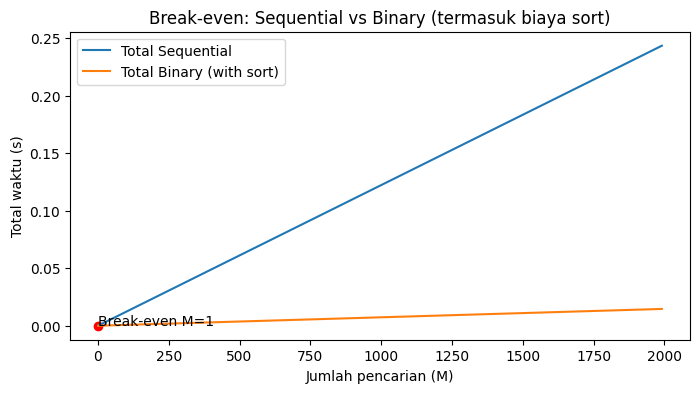

In [11]:
# Break-even Point Plot (include sort cost)
arr = np.random.randint(0, 10000, size=1000)
arr.sort()
# empirical sort time
sort_time = time_call(lambda x: np.sort(x), arr.copy())[0]
# average per-search times
repeats = 200
t_seq_list=[]
t_bin_list=[]
for _ in range(repeats):
    target = np.random.choice(arr)
    t_s, (_i,_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
    t_b, (_i,_s,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
    t_seq_list.append(t_s)
    t_bin_list.append(t_b)
avg_seq = np.mean(t_seq_list)
avg_bin = np.mean(t_bin_list)

Ms = np.arange(1,2001,10)
total_seq = Ms * avg_seq
total_bin = sort_time + Ms * avg_bin

# find crossover
cross_idx = np.where(total_bin < total_seq)[0]
cross_M = Ms[cross_idx[0]] if cross_idx.size>0 else None

plt.figure(figsize=(8,4))
plt.plot(Ms, total_seq, label='Total Sequential')
plt.plot(Ms, total_bin, label='Total Binary (with sort)')
if cross_M is not None:
    plt.scatter([cross_M], [sort_time + cross_M*avg_bin], color='red')
    plt.annotate(f'Break-even M={cross_M}', (cross_M, sort_time + cross_M*avg_bin))
plt.xlabel('Jumlah pencarian (M)')
plt.ylabel('Total waktu (s)')
plt.title('Break-even: Sequential vs Binary (termasuk biaya sort)')
plt.legend()
plt.show()


### Grouped Bar Chart Ditemukan vs Tidak Ditemukan

Membandingkan performa algoritma saat target ada vs tidak ada, sehingga terlihat perbedaan kondisi best case dan worst case.

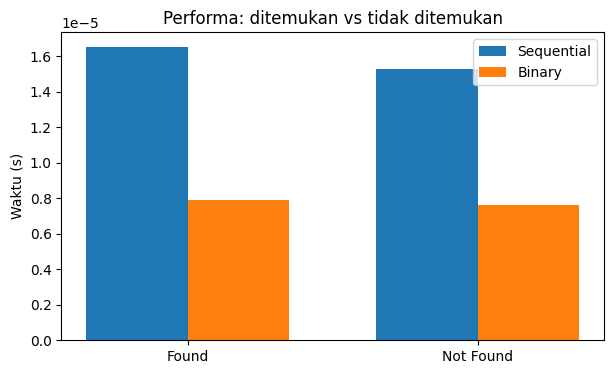

In [12]:
# 6) Stacked/Grouped Bar – Kondisi ditemukan vs tidak ditemukan
num_searches = len(data)
results_found = {'Sequential': [], 'Binary': []}
results_notfound = {'Sequential': [], 'Binary': []}
# ensure mixture of found and not-found
arr = data.copy()
for _ in range(num_searches):
    target = np.random.choice(arr)
    t_s, (_i,_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
    t_b, (_i,_s,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
    results_found['Sequential'].append(t_s)
    results_found['Binary'].append(t_b)
for _ in range(num_searches):
    target = 100000  # guaranteed not in arr
    t_s, (_i,_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
    t_b, (_i,_s,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
    results_notfound['Sequential'].append(t_s)
    results_notfound['Binary'].append(t_b)

labels = ['Found','Not Found']
seq_means = [np.mean(results_found['Sequential']), np.mean(results_notfound['Sequential'])]
bin_means = [np.mean(results_found['Binary']), np.mean(results_notfound['Binary'])]

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7,4))
plt.bar(x - width/2, seq_means, width, label='Sequential')
plt.bar(x + width/2, bin_means, width, label='Binary')
plt.xticks(x, labels)
plt.ylabel('Waktu (s)')
plt.title('Performa: ditemukan vs tidak ditemukan')
plt.legend()
plt.show()


### Tabel Hasil Pencarian per ID

Menyajikan data mentah tiap percobaan (ID, algoritma, waktu, langkah, status) sebagai bukti eksperimen detail.

In [13]:
# Table 1) Tabel hasil pencarian per ID
num_searches = len(data)
rows = []
arr = data.copy()
for i in range(num_searches):
    # alternate found / not found
    if i % 2 == 0:
        target = np.random.choice(arr)
    else:
        target = 100000 + i
    t_s, (idx_s, steps_s, found_s) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
    t_b, (idx_b, steps_b, found_b) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
    rows.append({'ID': i, 'Algoritma': 'Sequential', 'Waktu (detik)': t_s, 'Jumlah langkah': steps_s, 'Status': 'ditemukan' if found_s else 'tidak'})
    rows.append({'ID': i, 'Algoritma': 'Binary', 'Waktu (detik)': t_b, 'Jumlah langkah': steps_b, 'Status': 'ditemukan' if found_b else 'tidak'})

df_per_id = pd.DataFrame(rows)
df_per_id.head()


,ID,Algoritma,Waktu (detik),Jumlah langkah,Status
0,0,Sequential,0.000026,43,ditemukan
1,0,Binary,0.000020,6,ditemukan
2,1,Sequential,0.000017,52,tidak
3,1,Binary,0.000008,6,tidak
4,2,Sequential,0.000011,9,ditemukan


### Tabel Ringkasan Rata‑rata

Memberikan gambaran umum performa tiap algoritma (rata‑rata waktu, rata‑rata langkah, jumlah pencarian).

In [14]:
# Table 2) Tabel ringkasan rata-rata
summary = df_per_id.groupby('Algoritma').agg({'Waktu (detik)': 'mean', 'Jumlah langkah': 'mean', 'ID': 'count'}).rename(columns={'ID':'Jumlah pencarian'})
summary = summary.reset_index()
summary


,Algoritma,Waktu (detik),Jumlah langkah,Jumlah pencarian
0,Binary,0.000007,5.596154,52
1,Sequential,0.000022,41.346154,52


### Tabel Perbandingan Ukuran Dataset

Menunjukkan bagaimana perubahan ukuran data memengaruhi waktu dan langkah Sequential vs Binary.

In [15]:
# Table 3) Tabel perbandingan ukuran dataset
sizes = [10, 100, 1000, 5000]
rows = []
repeats = 50
for size in sizes:
    arr = np.random.randint(0, 10000, size=size)
    arr.sort()
    t_seq_list=[]; t_bin_list=[]
    s_seq_list=[]; s_bin_list=[]
    for _ in range(repeats):
        target = np.random.choice(arr)
        t_s, (_i,s_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
        t_b, (_i,s_b,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
        t_seq_list.append(t_s); t_bin_list.append(t_b)
        s_seq_list.append(s_s); s_bin_list.append(s_b)
    rows.append({'Ukuran dataset': size, 'Sequential waktu': np.mean(t_seq_list), 'Binary waktu': np.mean(t_bin_list), 'Sequential langkah': np.mean(s_seq_list), 'Binary langkah': np.mean(s_bin_list)})

df_sizes = pd.DataFrame(rows)
df_sizes


,Ukuran dataset,Sequential waktu,Binary waktu,Sequential langkah,Binary langkah
0,10,0.000002,0.000002,4.76,3.18
1,100,0.000006,0.000003,48.22,5.50
2,1000,0.000089,0.000005,501.48,8.70
3,5000,0.000358,0.000006,2497.58,11.08


### Tabel Break‑even Point

Menjelaskan pada jumlah pencarian berapa Binary lebih efisien setelah memperhitungkan biaya sort.

In [18]:
# Table 4) Tabel break-even point
# reuse arr, sort_time, avg_seq, avg_bin from previous cells if present; otherwise recompute
arr = np.random.randint(0, 10000, size=1000)
arr.sort()
sort_time = time_call(lambda x: np.sort(x), arr.copy())[0]
repeats = 200
t_seq_list=[]; t_bin_list=[]
for _ in range(repeats):
    target = np.random.choice(arr)
    t_s, (_i,_s,_f) = time_call(lambda a,t: sequential_search_with_steps(a,t), arr, target)
    t_b, (_i,_s,_f) = time_call(lambda a,t: binary_search_with_steps(a,t), arr, target)
    t_seq_list.append(t_s); t_bin_list.append(t_b)
avg_seq = np.mean(t_seq_list); avg_bin = np.mean(t_bin_list)
Ms = np.arange(1,2001,10)
total_seq = Ms * avg_seq
total_bin = sort_time + Ms * avg_bin
rows = []
for m, s_seq, s_bin in zip(Ms, total_seq, total_bin):
    better = 'Binary' if s_bin < s_seq else 'Sequential'
    rows.append({'Jumlah pencarian (M)': int(m), 'Total waktu Sequential': s_seq, 'Total waktu Binary': s_bin, 'Algoritma lebih efisien': better})

df_breakeven = pd.DataFrame(rows)
# show the first few and the calculated break-even (if any)
cross = df_breakeven[df_breakeven['Algoritma lebih efisien']=='Binary']
first_cross = cross.iloc[0] if len(cross)>0 else None
print('Break-even first row (if any):')
print(first_cross)

df_breakeven.head(16)


Break-even first row (if any):
Jumlah pencarian (M)              1
Total waktu Sequential     0.000083
Total waktu Binary         0.000038
Algoritma lebih efisien      Binary
Name: 0, dtype: object


,Jumlah pencarian (M),Total waktu Sequential,Total waktu Binary,Algoritma lebih efisien
0,1,0.000083,0.000038,Binary
1,11,0.000914,0.000093,Binary
2,21,0.001746,0.000148,Binary
3,31,0.002577,0.000203,Binary
4,41,0.003408,0.000258,Binary
5,51,0.004240,0.000313,Binary
6,61,0.005071,0.000368,Binary
7,71,0.005903,0.000423,Binary
8,81,0.006734,0.000478,Binary
9,91,0.007565,0.000533,Binary
